# News Sentiment Collector

Collects stock news sentiment from Alpha Vantage and Polygon.io.
StockTwits is blocked by Cloudflare — these two APIs are reliable free alternatives.

## Setup
1. Get free Alpha Vantage key: https://www.alphavantage.co/support/#api-key
2. Get free Polygon key: https://polygon.io
3. Set both keys in Section 1 below
4. Run sections in order

## Output
Saves to `stocktwits_data/` folder in your main GitHub repo for compatibility with sentiment engine.

---
## 0. Install

In [1]:
# !pip install requests pandas python-dotenv

---
## 1. Configuration — Set your API keys here

In [2]:
import os, io, time, base64, requests
import pandas as pd
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

# ── SET YOUR API KEYS HERE ────────────────────────────────────────────
ALPHA_VANTAGE_KEY = 'K2LWKT4WF5VGZ7L1'   # https://www.alphavantage.co/support/#api-key
POLYGON_KEY       = 'U4a3par_XFu0VR3LqR_xNo7RxDOPnWkN'   # https://polygon.io
# ─────────────────────────────────────────────────────────────────────

GITHUB_REPO   = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN  = os.environ.get('GITHUB_TOKEN', None)
ST_PREFIX     = 'stocktwits_data'
GITHUB_API    = 'https://api.github.com'

TICKERS = [
    'AAPL','MSFT','GOOGL','META','AMZN','NVDA','TSLA','AMD','INTC',
    'TSM','QCOM','COIN','PYPL','NFLX','CRM','CRWD','PANW','PLTR',
    'DDOG','SNOW','MDB','NOW','OKTA','NVO','INCY','KGC','PM','WPM',
    'SPY','QQQ',
]

print('Configuration loaded')
print(f'  Alpha Vantage : {"set" if ALPHA_VANTAGE_KEY != "YOUR_KEY_HERE" else "NOT SET"}')
print(f'  Polygon       : {"set" if POLYGON_KEY != "YOUR_KEY_HERE" else "NOT SET"}')
print(f'  GitHub token  : {"set" if GITHUB_TOKEN else "NOT SET"}')
print(f'  Tickers       : {len(TICKERS)}')

Configuration loaded
  Alpha Vantage : set
  Polygon       : set
  GitHub token  : set
  Tickers       : 30


---
## 2. GitHub helpers

In [3]:
def _gh_headers(token):
    return {'Authorization': f'Bearer {token}',
            'Accept': 'application/vnd.github+json',
            'X-GitHub-Api-Version': '2022-11-28'}

def push_csv(df, path, token, msg=None):
    if msg is None: msg = f'Update {path} - {len(df):,} rows'
    buf = io.StringIO(); df.to_csv(buf, index=False)
    encoded = base64.b64encode(buf.getvalue().encode()).decode()
    url = f'{GITHUB_API}/repos/{GITHUB_REPO}/contents/{path}'
    headers = _gh_headers(token)
    check = requests.get(url, headers=headers, timeout=15)
    sha = check.json().get('sha') if check.status_code == 200 else None
    payload = {'message': msg, 'content': encoded}
    if sha: payload['sha'] = sha
    for attempt in range(3):
        resp = requests.put(url, headers=headers, json=payload, timeout=120)
        if resp.status_code in (200, 201):
            print(f'  Saved {path} ({len(df):,} rows)')
            return True
        if resp.status_code == 409 and attempt < 2:
            time.sleep(3)
            check = requests.get(url, headers=headers, timeout=15)
            sha = check.json().get('sha') if check.status_code == 200 else None
            if sha: payload['sha'] = sha
        else:
            print(f'  FAILED {path}: {resp.status_code}')
            return False

def load_csv(path, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{path}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404: raise FileNotFoundError(path)
    resp.raise_for_status()
    content = resp.text.strip()
    if not content: return pd.DataFrame()
    return pd.read_csv(io.StringIO(content), low_memory=False)

print('GitHub helpers loaded')

GitHub helpers loaded


---
## 3. API Functions

In [4]:
def fetch_alphavantage_news(ticker, limit=200):
    url = 'https://www.alphavantage.co/query'
    params = {'function': 'NEWS_SENTIMENT', 'tickers': ticker,
              'limit': limit, 'apikey': ALPHA_VANTAGE_KEY}
    try:
        resp = requests.get(url, params=params, timeout=30)
        if resp.status_code != 200: return []
        return resp.json().get('feed', [])
    except Exception as e:
        print(f'  Alpha Vantage error: {e}')
        return []

def av_to_df(articles, ticker):
    if not articles: return pd.DataFrame()
    rows = []
    for a in articles:
        ticker_sent = 0.0
        relevance   = 0.0
        for ts in a.get('ticker_sentiment', []):
            if ts.get('ticker') == ticker:
                ticker_sent = float(ts.get('ticker_sentiment_score', 0))
                relevance   = float(ts.get('relevance_score', 0))
                break
        time_str = a.get('time_published', '')
        try:    dt = pd.to_datetime(time_str, format='%Y%m%dT%H%M%S')
        except: dt = None
        rows.append({
            'id'             : a.get('url','')[-50:],
            'ticker'         : ticker,
            'title'          : a.get('title',''),
            'body'           : a.get('summary','')[:500],
            'source'         : a.get('source',''),
            'url'            : a.get('url',''),
            'created_at'     : str(dt) if dt else '',
            'date'           : str(dt.date()) if dt else None,
            'year'           : dt.year  if dt else None,
            'month'          : dt.month if dt else None,
            'overall_sentiment': float(a.get('overall_sentiment_score', 0)),
            'ticker_sentiment' : ticker_sent,
            'relevance_score'  : relevance,
            'st_sentiment'   : 'Bullish' if ticker_sent > 0.15
                               else ('Bearish' if ticker_sent < -0.15 else ''),
            'likes'          : 0,
            'user_followers' : 0,
        })
    return pd.DataFrame(rows)

def fetch_polygon_news(ticker, limit=50):
    url = 'https://api.polygon.io/v2/reference/news'
    params = {'ticker': ticker, 'limit': limit,
              'order': 'desc', 'apiKey': POLYGON_KEY}
    try:
        resp = requests.get(url, params=params, timeout=30)
        if resp.status_code != 200: return []
        return resp.json().get('results', [])
    except Exception as e:
        print(f'  Polygon error: {e}')
        return []

def polygon_to_df(news, ticker):
    if not news: return pd.DataFrame()
    rows = []
    for n in news:
        dt_str = n.get('published_utc','')
        try:    dt = pd.to_datetime(dt_str)
        except: dt = None
        rows.append({
            'id'             : n.get('id',''),
            'ticker'         : ticker,
            'title'          : n.get('title',''),
            'body'           : n.get('description','')[:500],
            'source'         : n.get('publisher',{}).get('name',''),
            'url'            : n.get('article_url',''),
            'created_at'     : dt_str,
            'date'           : str(dt.date()) if dt else None,
            'year'           : dt.year  if dt else None,
            'month'          : dt.month if dt else None,
            'overall_sentiment': 0.0,
            'ticker_sentiment' : 0.0,
            'relevance_score'  : 1.0,
            'st_sentiment'   : '',
            'likes'          : 0,
            'user_followers' : 0,
        })
    return pd.DataFrame(rows)

def fetch_fear_greed():
    try:
        resp = requests.get('https://api.alternative.me/fng/?limit=365&format=json', timeout=20)
        if resp.status_code != 200: return pd.DataFrame()
        rows = [{'date': pd.to_datetime(int(d['timestamp']), unit='s').date(),
                 'fear_greed_value': int(d['value']),
                 'fear_greed_label': d['value_classification']}
                for d in resp.json().get('data',[])]
        return pd.DataFrame(rows)
    except Exception as e:
        print(f'  Fear & Greed error: {e}')
        return pd.DataFrame()

# Sanity check
print('Testing APIs ...')
if ALPHA_VANTAGE_KEY != 'YOUR_KEY_HERE':
    arts = fetch_alphavantage_news('NVDA', limit=3)
    print(f'  Alpha Vantage: {len(arts)} articles for NVDA')
    if arts: print(f'  Sample: {arts[0].get("title","")[:70]}')
else:
    print('  Alpha Vantage: key not set')

if POLYGON_KEY != 'YOUR_KEY_HERE':
    news = fetch_polygon_news('NVDA', limit=3)
    print(f'  Polygon: {len(news)} articles for NVDA')
    if news: print(f'  Sample: {news[0].get("title","")[:70]}')
else:
    print('  Polygon: key not set')

df_fg = fetch_fear_greed()
if not df_fg.empty:
    latest = df_fg.iloc[0]
    print(f'  Fear & Greed: {len(df_fg)} days, today={latest["fear_greed_value"]} ({latest["fear_greed_label"]})')
else:
    print('  Fear & Greed: could not fetch')

Testing APIs ...
  Alpha Vantage: 50 articles for NVDA
  Sample: Welch & Forbes LLC Cuts Position in Bank of America Corporation $BAC
  Polygon: 3 articles for NVDA
  Sample: The 1 AI Stock I'd Buy and Hold for the Next Decade
  Fear & Greed: 365 days, today=26 (Fear)


---
## 4. Full Fetch — All Tickers

In [5]:
if GITHUB_TOKEN is None:
    print('GITHUB_TOKEN not set — cannot save to GitHub')
elif ALPHA_VANTAGE_KEY == 'YOUR_KEY_HERE' and POLYGON_KEY == 'YOUR_KEY_HERE':
    print('Set at least one API key in Section 1 before running')
else:
    index_rows = []

    for i, ticker in enumerate(TICKERS, 1):
        print(f'[{i}/{len(TICKERS)}] {ticker} ...')
        path = f'{ST_PREFIX}/stocktwits_{ticker}.csv'

        try:
            df_existing = load_csv(path, GITHUB_TOKEN)
        except FileNotFoundError:
            df_existing = pd.DataFrame()

        frames = []

        # Alpha Vantage
        if ALPHA_VANTAGE_KEY != 'YOUR_KEY_HERE':
            arts = fetch_alphavantage_news(ticker, limit=200)
            if arts:
                df_av = av_to_df(arts, ticker)
                frames.append(df_av)
                print(f'  AV: {len(df_av)} articles')
            time.sleep(12)  # free tier: 5 req/min

        # Polygon
        if POLYGON_KEY != 'YOUR_KEY_HERE':
            news = fetch_polygon_news(ticker, limit=50)
            if news:
                df_poly = polygon_to_df(news, ticker)
                frames.append(df_poly)
                print(f'  Polygon: {len(df_poly)} articles')
            time.sleep(13)  # free tier: 5 req/min

        if not frames:
            print(f'  No articles found')
            continue

        df_new = pd.concat(frames, ignore_index=True).drop_duplicates(subset='id')

        if not df_existing.empty:
            df_combined = (
                pd.concat([df_existing, df_new], ignore_index=True)
                .drop_duplicates(subset='id')
                .sort_values('date', ascending=False)
                .reset_index(drop=True)
            )
        else:
            df_combined = df_new.sort_values('date', ascending=False).reset_index(drop=True)

        push_csv(df_combined, path, GITHUB_TOKEN,
                 f'News sentiment {ticker}: {len(df_combined):,} articles')

        index_rows.append({
            'ticker'    : ticker,
            'post_count': len(df_combined),
            'date_min'  : df_combined['date'].min(),
            'date_max'  : df_combined['date'].max(),
            'bullish'   : (df_combined['st_sentiment']=='Bullish').sum(),
            'bearish'   : (df_combined['st_sentiment']=='Bearish').sum(),
        })

    # Fear & Greed
    df_fg = fetch_fear_greed()
    if not df_fg.empty:
        push_csv(df_fg, f'{ST_PREFIX}/fear_greed.csv', GITHUB_TOKEN,
                 f'Fear & Greed: {len(df_fg)} days')

    if index_rows:
        df_idx = pd.DataFrame(index_rows).sort_values('ticker')
        push_csv(df_idx, f'{ST_PREFIX}/stocktwits_index.csv', GITHUB_TOKEN,
                 f'News sentiment index: {df_idx["post_count"].sum():,} total')
        print(f'\nDone! Total articles: {df_idx["post_count"].sum():,}')
        print(df_idx.to_string(index=False))

[1/30] AAPL ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_AAPL.csv (98 rows)
[2/30] MSFT ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_MSFT.csv (100 rows)
[3/30] GOOGL ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_GOOGL.csv (100 rows)
[4/30] META ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_META.csv (100 rows)
[5/30] AMZN ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_AMZN.csv (100 rows)
[6/30] NVDA ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_NVDA.csv (98 rows)
[7/30] TSLA ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_TSLA.csv (100 rows)
[8/30] AMD ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_AMD.csv (93 rows)
[9/30] INTC ...
  AV: 50 articles
  Polygon: 50 articles
  Saved stocktwits_data/stocktwits_INTC.csv (99 ro

---
## 5. Incremental Update

Run this weekly to fetch only new articles.

In [6]:
if GITHUB_TOKEN is None:
    print('GITHUB_TOKEN not set')
elif ALPHA_VANTAGE_KEY == 'YOUR_KEY_HERE' and POLYGON_KEY == 'YOUR_KEY_HERE':
    print('Set at least one API key in Section 1')
else:
    print('Running incremental update ...')
    for ticker in TICKERS:
        path = f'{ST_PREFIX}/stocktwits_{ticker}.csv'
        try:
            df_existing = load_csv(path, GITHUB_TOKEN)
            latest_date = df_existing['date'].max()
        except FileNotFoundError:
            df_existing = pd.DataFrame()
            latest_date = None

        frames = []
        if ALPHA_VANTAGE_KEY != 'YOUR_KEY_HERE':
            arts = fetch_alphavantage_news(ticker, limit=50)
            if arts:
                df_av = av_to_df(arts, ticker)
                if latest_date:
                    df_av = df_av[df_av['date'] > latest_date]
                frames.append(df_av)
            time.sleep(12)

        if not frames or all(f.empty for f in frames):
            continue

        df_new = pd.concat(frames, ignore_index=True).drop_duplicates(subset='id')
        if df_new.empty: continue

        df_combined = (
            pd.concat([df_existing, df_new], ignore_index=True)
            .drop_duplicates(subset='id')
            .sort_values('date', ascending=False)
            .reset_index(drop=True)
        ) if not df_existing.empty else df_new

        push_csv(df_combined, path, GITHUB_TOKEN,
                 f'Update {ticker}: +{len(df_new)} new articles')
        print(f'  {ticker}: +{len(df_new)} new articles')
    print('Incremental update complete')

Running incremental update ...
Incremental update complete


---
## 6. Coverage Check

Total articles: 2,312
ticker  post_count   date_min   date_max  bullish  bearish
  AAPL          98 2026-07-03 2026-07-12       14       11
   AMD          93 2026-06-25 2026-07-12       31        1
  AMZN         100 2026-07-07 2026-07-12       20        2
  COIN         100 2026-05-04 2026-07-12        1        2
   CRM         100 2026-05-27 2026-07-12       21        4
  CRWD          99 2026-05-31 2026-07-11       20       13
  DDOG          50 2025-08-18 2026-07-11        0        0
 GOOGL         100 2026-07-08 2026-07-12       17        6
  INCY          50 2024-01-15 2026-06-09        0        0
  INTC          99 2026-06-27 2026-07-12       16        9
   KGC          50 2025-05-27 2026-07-11        0        0
   MDB          50 2025-06-18 2026-07-02        0        0
  META         100 2026-07-07 2026-07-12       38        3
  MSFT         100 2026-07-08 2026-07-12       20        2
  NFLX          98 2026-06-03 2026-07-12       16        5
   NOW          50 2026-04-24 2026

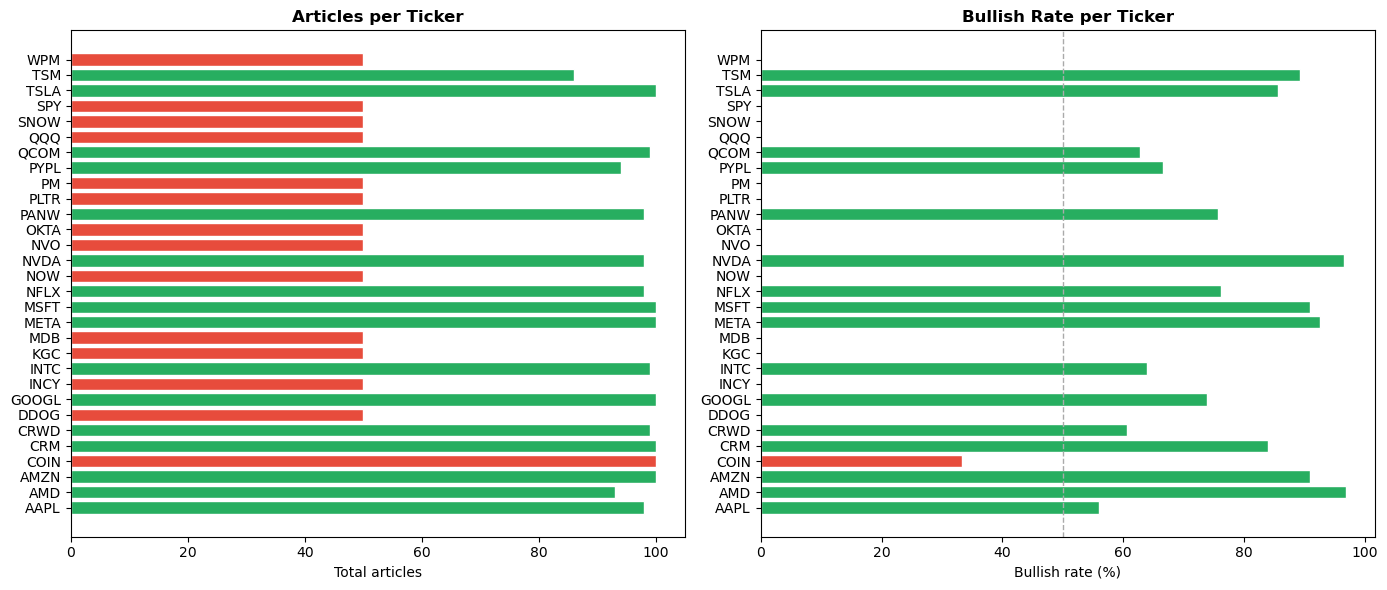

In [7]:
import matplotlib.pyplot as plt

try:
    df_idx = load_csv(f'{ST_PREFIX}/stocktwits_index.csv', GITHUB_TOKEN)
    df_idx['bullish_rate'] = df_idx['bullish'] / (df_idx['bullish'] + df_idx['bearish'] + 0.001)
    print(f'Total articles: {df_idx["post_count"].sum():,}')
    print(df_idx[['ticker','post_count','date_min','date_max','bullish','bearish']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
    axes[0].barh(df_idx['ticker'], df_idx['post_count'],
                 color=['#27ae60' if r>=0.5 else '#e74c3c' for r in df_idx['bullish_rate']],
                 edgecolor='white')
    axes[0].set_xlabel('Total articles')
    axes[0].set_title('Articles per Ticker', fontweight='bold')
    axes[0].set_facecolor('white')
    axes[1].barh(df_idx['ticker'], df_idx['bullish_rate']*100,
                 color=['#27ae60' if r>=50 else '#e74c3c' for r in df_idx['bullish_rate']*100],
                 edgecolor='white')
    axes[1].axvline(50, color='#aaaaaa', linewidth=1, linestyle='--')
    axes[1].set_xlabel('Bullish rate (%)')
    axes[1].set_title('Bullish Rate per Ticker', fontweight='bold')
    axes[1].set_facecolor('white')
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('No index yet — run Section 4 first')